In [1]:
%cd ../..

f:\nn


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

import optuna

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utils.training import train_model, evaluate_model
from utils.visualization import plot_training_curves, plot_confusion_matrix
from utils.dataset import CrackDataset
from utils.config import TRANSFER_CONFIG, TRANSFER_SEARCH_SPACE
from utils.hparam_search import run_search, plot_search_results

f:\nn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importing our dataset

,class,resized_path
0,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
1,Non Cracked,data\augmented_images\7050-6_resized_aug2.jpeg
2,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
3,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
4,Non Cracked,data\augmented_images\7119-100_resized_aug2.jpeg
5,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
6,Non Cracked,data\augmented_images\14397_resized_aug0.jpeg
7,Non Cracked,data\augmented_images\16418_resized_aug0.jpeg
8,Non Cracked,data\augmented_images\047-50_resized_aug1.jpeg
9,Non Cracked,data\augmented_images\7103-214_resized_aug1.jpeg


Class distribution:


<Axes: xlabel='class'>

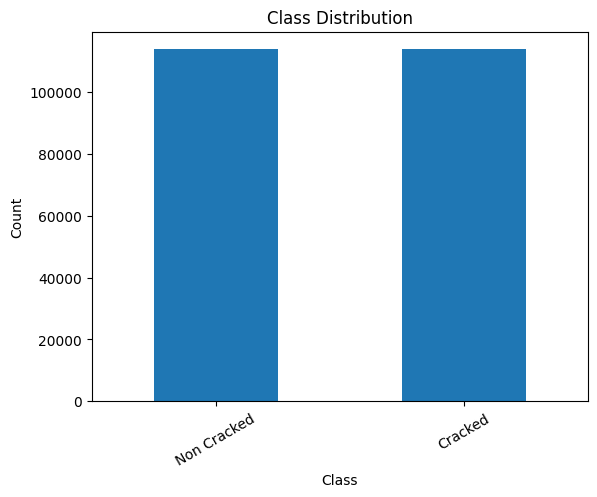

In [3]:
df = pd.read_csv('data/trainable_df.csv')
display(df.head(10))
print("="*80)
print("Class distribution:")
display(df['class'].value_counts().plot(kind='bar'))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Preparing our data

## Image preprocessing

> Transfer learning leverages a backbone (here, ResNet18) that was pretrained on ImageNet — a 1.2M-image, 1000-class dataset of natural photos. The backbone has already learned generic low-level features (edges, textures, shapes) that transfer well to most image tasks, so we only need to teach it the crack-specific patterns.

> Three preprocessing constraints come from the pretrained weights:
> 1. **Input size 224x224** — what ResNet was trained on.
> 2. **3-channel RGB** — our crack images are grayscale, so we replicate the single channel three times (`x.repeat(3, 1, 1)`). This is cheaper than re-training the first conv layer to accept 1 channel.
> 3. **ImageNet normalization** — `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`. The pretrained weights expect inputs in this distribution; using `[0.5]/[0.5]` would silently degrade performance.

In [4]:
eval_transformations = transforms.Compose([
    transforms.Resize((TRANSFER_CONFIG['image_size'], TRANSFER_CONFIG['image_size'])),
    transforms.Lambda(lambda img: transforms.functional.adjust_contrast(img, 2.0)),
    transforms.ToTensor(),                                   # (1, H, W)
    transforms.Normalize(mean=[0.449], std=[0.226]),         # ImageNet RGB stats averaged
])

train_transformations = transforms.Compose([
    transforms.Resize((TRANSFER_CONFIG['image_size'], TRANSFER_CONFIG['image_size'])),
    transforms.Lambda(lambda img: transforms.functional.adjust_contrast(img, 2.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.449], std=[0.226]),
])

classes = sorted(df['class'].unique())
train_full = CrackDataset(df, transform=train_transformations, classes=classes)
eval_full  = CrackDataset(df, transform=eval_transformations,  classes=classes)

n = len(train_full)
train_size = int(n * 0.8)
val_size   = int(n * 0.1)
test_size  = n - train_size - val_size

train_dataset, _, _ = random_split(train_full, [train_size, val_size, test_size],
                                   generator=torch.Generator().manual_seed(42))
_, val_dataset, test_dataset = random_split(eval_full, [train_size, val_size, test_size],
                                            generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"Classes: {classes}")
print(f"Class→idx: {train_full.class_to_idx}")

Train: 182,297  |  Val: 22,787  |  Test: 22,788
Classes: ['Cracked', 'Non Cracked']
Class→idx: {'Cracked': 0, 'Non Cracked': 1}


# Initializing the DataLoader

The `DataLoader` wraps each split in a batched iterator. `shuffle=True` on the training set prevents the model from memorising sample order. Validation and test loaders use `shuffle=False` so metrics are fully reproducible.

In [5]:
train_loader = DataLoader(train_dataset, batch_size=TRANSFER_CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=TRANSFER_CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=TRANSFER_CONFIG['batch_size'], shuffle=False, num_workers=0)

# Transfer Learning Architecture

We load a ResNet18 with ImageNet-pretrained weights and replace its final fully-connected layer (1000-class ImageNet head) with a new `Dropout -> Linear` head sized for our binary task. All weights — both backbone and head — remain trainable, so the entire network is fine-tuned end-to-end.

Why full fine-tuning over feature extraction? On a dataset of ~228k images the backbone has plenty of signal to adapt to crack textures, and the gap between fine-tuning and frozen-backbone accuracy on this kind of task is typically several points.

In [6]:
class TransferLearning(nn.Module):
    """
    ResNet18 (ImageNet-pretrained) fine-tuned for binary crack classification.

    conv1 is converted from 3-channel to 1-channel input by averaging the
    pretrained kernel along the input-channel dim, preserving most of the
    learned ImageNet features.

    Input shape:  (batch, 1, 224, 224)
    Output shape: (batch, num_classes)
    """

    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # Convert conv1 from 3-channel to 1-channel, preserving pretrained features.
        old_conv1 = self.backbone.conv1
        new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv1.weight.copy_(old_conv1.weight.mean(dim=1, keepdim=True))
        self.backbone.conv1 = new_conv1

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


model = TransferLearning(num_classes=len(classes), dropout=TRANSFER_CONFIG['dropout'])

In [7]:
print(resnet18())


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Training

## Device Setup

PyTorch runs on CPU or CUDA (NVIDIA GPU). Training on a GPU is orders of magnitude faster for batch matrix operations. `torch.cuda.is_available()` selects the GPU automatically when one is present.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cuda


## Hyperparameter Search

Rather than manually tuning learning rate, dropout, weight decay, and batch size, we use **Optuna** to search the space automatically over 30 trials. The search range for `lr` is narrower and lower than the from-scratch models (1e-5 to 1e-3) because pretrained weights need gentler updates — too high a learning rate destroys the ImageNet features we are trying to leverage.

`build_transfer` is a factory function — given a `params` dict and `num_classes`, it constructs and returns the model, optimiser, scheduler, and loss criterion. `run_search` passes it to each trial with a sampled parameter set, trains briefly on 30 % of the data (pre-loaded into RAM), and returns the best-performing configuration.

In [9]:
from utils.hparam_search import _make_optimizer, _make_scheduler

def build_transfer(params, num_classes):
    model     = TransferLearning(num_classes=num_classes, dropout=params['dropout'])
    optimizer = _make_optimizer(params['optimizer'], model.parameters(),
                                params['lr'], params['weight_decay'])
    scheduler = _make_scheduler(params['scheduler'], optimizer, epochs=50)
    criterion = nn.CrossEntropyLoss()
    return model, optimizer, scheduler, criterion

In [10]:
best_params, trial_histories = run_search(
    build_transfer,
    train_loader, val_loader,
    TRANSFER_SEARCH_SPACE,
    classes,
    results_path='Models/transfer_learning/best_hparams.json',
)


Trial 1/30 — lr=2.84e-05, weight_decay=1.62e-05, dropout=1.46e-01, batch_size=32


Epoch 1/50 [val]: 100%|██████████| 178/178 [00:23<00:00,  7.51it/s]

Epoch 1/50 | Train Loss: 0.4871 | Train Acc: 0.7795 | Val Loss: 0.4489 | Val Acc: 0.7958 | LR: 2.84e-05



Epoch 2/50 [val]: 100%|██████████| 178/178 [00:11<00:00, 14.99it/s]

Epoch 2/50 | Train Loss: 0.4357 | Train Acc: 0.8192 | Val Loss: 0.4409 | Val Acc: 0.8014 | LR: 2.84e-05


...

Epoch 5/50 | Train Loss: 0.3209 | Train Acc: 0.9311 | Val Loss: 0.4932 | Val Acc: 0.8058 | LR: 2.61e-05



Epoch 6/50 [val]: 100%|██████████| 178/178 [00:11<00:00, 15.87it/s]

Epoch 6/50 | Train Loss: 0.2911 | Train Acc: 0.9561 | Val Loss: 0.5159 | Val Acc: 0.8067 | LR: 1.30e-05



Epoch 7/50 [val]: 100%|██████████| 178/178 [00:11<00:00, 15.27it/s]

Epoch 7/50 | Train Loss: 0.2645 | Train Acc: 0.9725 | Val Loss: 0.5276 | Val Acc: 0.8021 | LR: 1.30e-05
Early stopping at epoch 7 (no improvement for 5 epochs)
  -> best val_loss=0.4421 over 7 epochs

Best trial #14  val_loss=0.4320
Params: {'lr': 0.0001181684566433231, 'weight_decay': 3.400667132702287e-05, 'dropout': 0.21115340724200016, 'batch_size': 64}
Saved to Models\transfer_learning\best_hparams.json


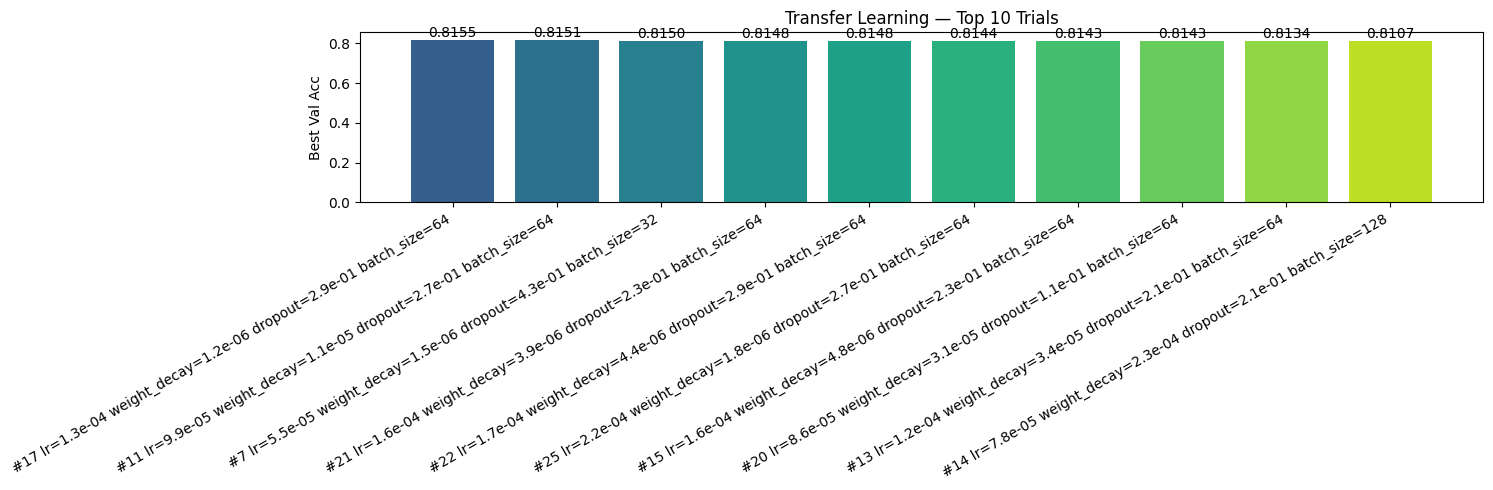

In [11]:
plot_search_results(trial_histories, metric='val_acc', title='Transfer Learning — Top 10 Trials', top_n=10)

## Final Training with Best Parameters

`TRANSFER_CONFIG` is updated with the best hyperparameters found by Optuna. `train_model` then calls `build_transfer` internally to construct the model, so it trains from scratch on the full training set with those parameters. The best checkpoint (lowest validation loss) is saved automatically.

In [12]:
TRANSFER_CONFIG.update(best_params)
model     = TransferLearning(num_classes=len(classes), dropout=TRANSFER_CONFIG['dropout'])
optimizer = torch.optim.Adam(model.parameters(),
                              lr=TRANSFER_CONFIG['lr'],
                              weight_decay=TRANSFER_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [13]:
history = train_model(build_transfer, train_loader, val_loader,
                      params=best_params, num_classes=len(classes),
                      epochs=TRANSFER_CONFIG['epochs'], device=device,
                      patience=TRANSFER_CONFIG['patience'],
                      save_path='Models/saved_models/transfer_best.pth')

Epoch 1/30 [val]: 100%|██████████| 357/357 [02:16<00:00,  2.61it/s]

Epoch 1/30 | Train Loss: 0.4473 | Train Acc: 0.8046 | Val Loss: 0.4226 | Val Acc: 0.8170 | LR: 1.18e-04


  -> Saved best model (val_loss=0.4226)


Epoch 2/30 [val]: 100%|██████████| 357/357 [00:43<00:00,  8.25it/s]

Epoch 2/30 | Train Loss: 0.4146 | Train Acc: 0.8258 | Val Loss: 0.4098 | Val Acc: 0.8273 | LR: 1.18e-04


...

Epoch 7/30 | Train Loss: 0.3514 | Train Acc: 0.8750 | Val Loss: 0.4115 | Val Acc: 0.8229 | LR: 1.18e-04



Epoch 8/30 [val]: 100%|██████████| 357/357 [00:43<00:00,  8.23it/s]

Epoch 8/30 | Train Loss: 0.3456 | Train Acc: 0.8810 | Val Loss: 0.4147 | Val Acc: 0.8184 | LR: 5.91e-05



Epoch 9/30 [val]: 100%|██████████| 357/357 [00:43<00:00,  8.19it/s]

Epoch 9/30 | Train Loss: 0.3279 | Train Acc: 0.8990 | Val Loss: 0.4239 | Val Acc: 0.8183 | LR: 5.91e-05
Early stopping at epoch 9 (no improvement for 5 epochs)


# Training Curves

Training and validation curves show how loss and accuracy evolved per epoch. The red dashed line marks the epoch where validation loss was lowest — the checkpoint saved at that point is the model we reload for evaluation.

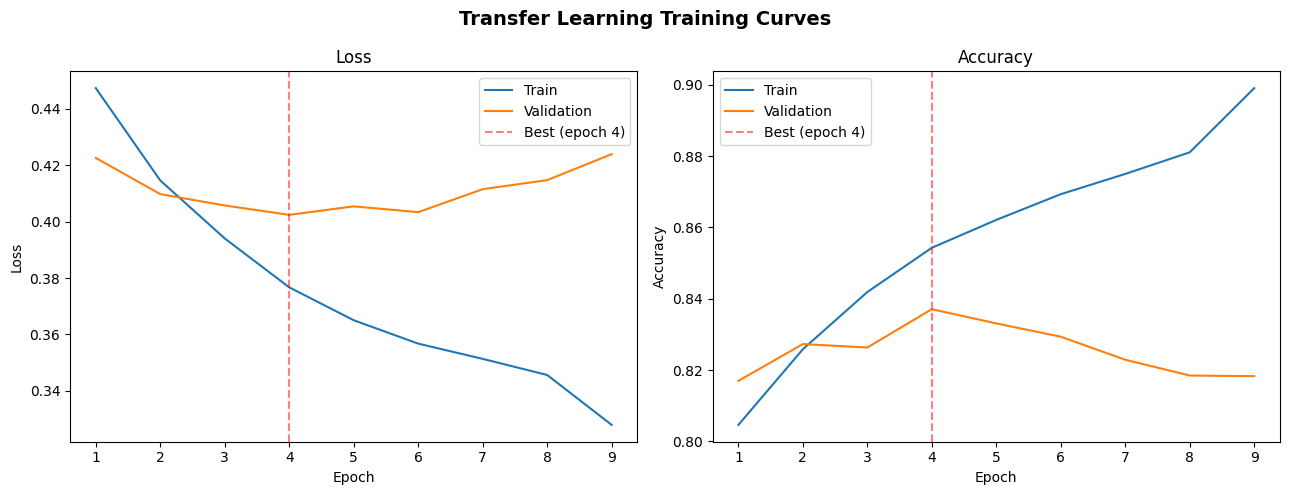

In [14]:
plot_training_curves(history, title='Transfer Learning Training Curves')

# Evaluation

We reload the best checkpoint before running inference — `train_model` saves it during training but the `model` variable in memory holds the last epoch, not the best one.

In [15]:
model = TransferLearning(num_classes=len(classes), dropout=TRANSFER_CONFIG['dropout'])
checkpoint = torch.load('Models/saved_models/transfer_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"| val_loss={checkpoint['val_loss']:.4f} | val_acc={checkpoint['val_acc']:.4f}")
model.to(device)

Loaded best model from epoch 4 | val_loss=0.4024 | val_acc=0.8371


TransferLearning(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

Classification Report:
              precision    recall  f1-score   support

     Cracked       0.84      0.83      0.83     11341
 Non Cracked       0.83      0.84      0.84     11447

    accuracy                           0.84     22788
   macro avg       0.84      0.84      0.84     22788
weighted avg       0.84      0.84      0.84     22788



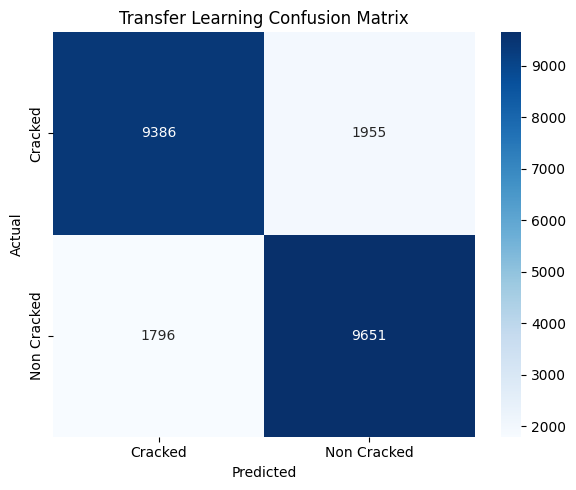

In [16]:
all_preds, all_labels = evaluate_model(model, test_loader, device=device)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))
plot_confusion_matrix(all_labels, all_preds, class_names=classes, title='Transfer Learning Confusion Matrix')